# Data Scraping

To forecast DK1 electricity prices, we first need data that describes both the price itself and the conditions that influence it. We collect day-ahead prices, electricity consumption, observed weather, and previous-run weather forecasts. The raw files are saved in `data/` and then transformed before they are passed to the model.

| Data | Why it is needed | Saved file |
|------|------------------|------------|
| Day-ahead prices | Target variable: the price we want to predict | `data/day_ahead_prices_dk1_raw.csv` |
| Weather actuals | Historical weather base for building forecast-like features | `data/weather_actuals_raw.csv` |
| Weather forecasts | Used to estimate realistic forecast errors by horizon | `data/weather_forecasts_raw.csv` |
| Consumption | Grid/load context used later in the resilience analysis | `data/consumption_dk1_raw.csv` |

All raw datasets come from Energi Data Service and Open-Meteo and can be collected with one call:

In [ ]:
from src.data.data_collection import fetch_all

results = fetch_all(start="2021-01-01", end="2026-04-28", price_area="DK1")

As a quick check, we plot prices and actual weather for the same period. This shows that the scraped time series line up and that weather conditions move in ways that are relevant for electricity prices.

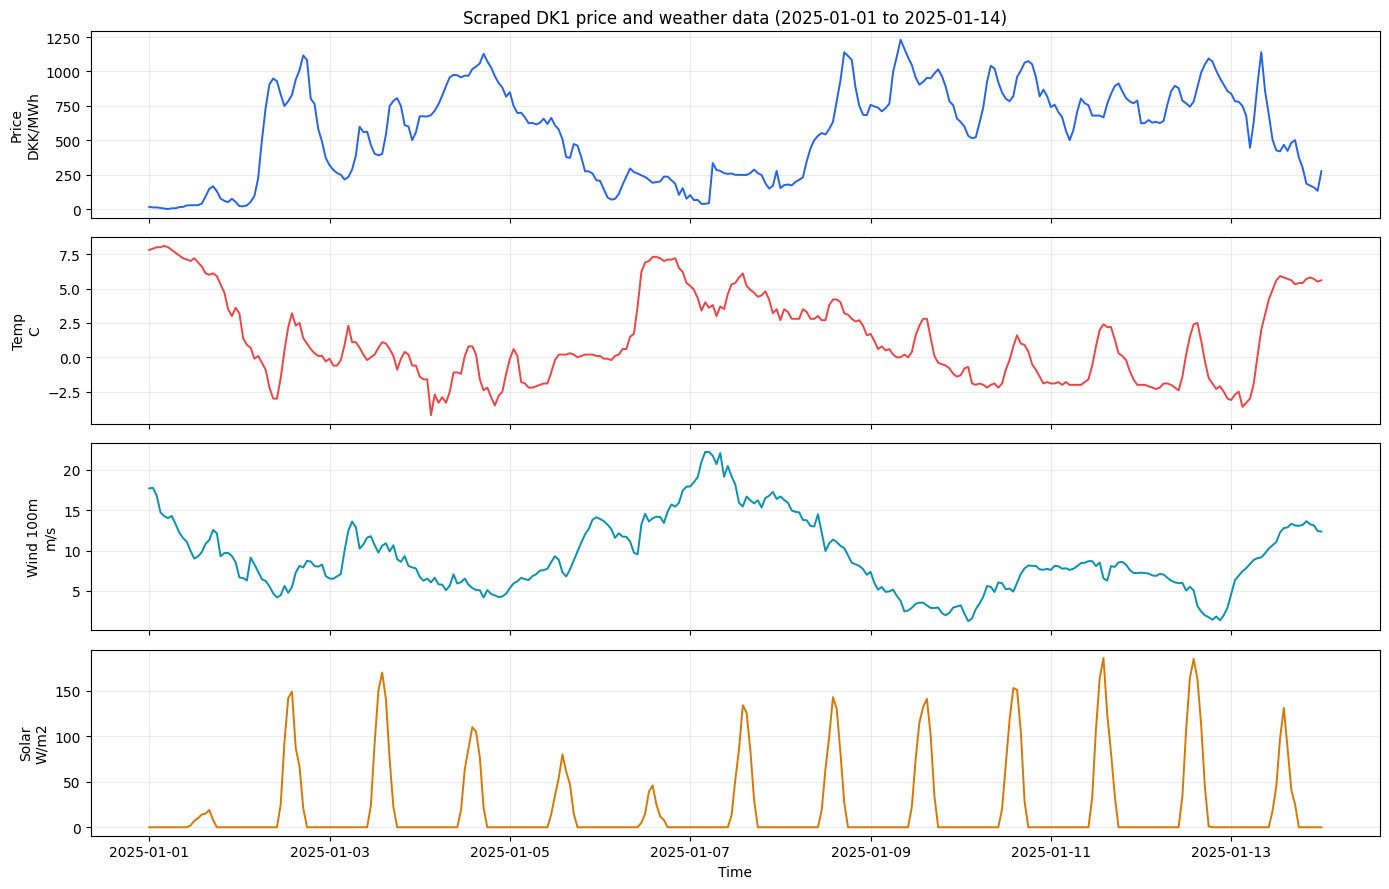

In [11]:
from src.analysis.forecast_analysis import plot_raw_price_and_weather

fig = plot_raw_price_and_weather(start="2025-01-01", end="2025-01-14")

The weather variables appear useful for predicting DK1 electricity prices, especially because several price spikes occur at the same time as changes in wind, temperature, or solar production. The clearest signal seems to be wind: when wind speeds are low, prices often rise, while periods with stronger wind tend to coincide with lower prices.

# Processing

Before this data can be used for prediction, there is one important issue: in a real forecast setting we do not know future weather actuals. The model should therefore not be trained on perfect future weather observations. It needs weather variables that look like forecasts.

The challenge is that real previous-run weather forecasts are only available from 2025 onwards. To cover the full modelling period from 2021, we use the available real forecasts to measure typical forecast errors, and then use those errors to simulate forecast-like weather data for the earlier period.

The data processing script does this in two steps: first it estimates weather forecast error distributions, and then it builds the final forecast dataset used by the model.

The first processing output is `weather_error_distributions.csv`. The plot below shows how forecast errors change across horizons. 

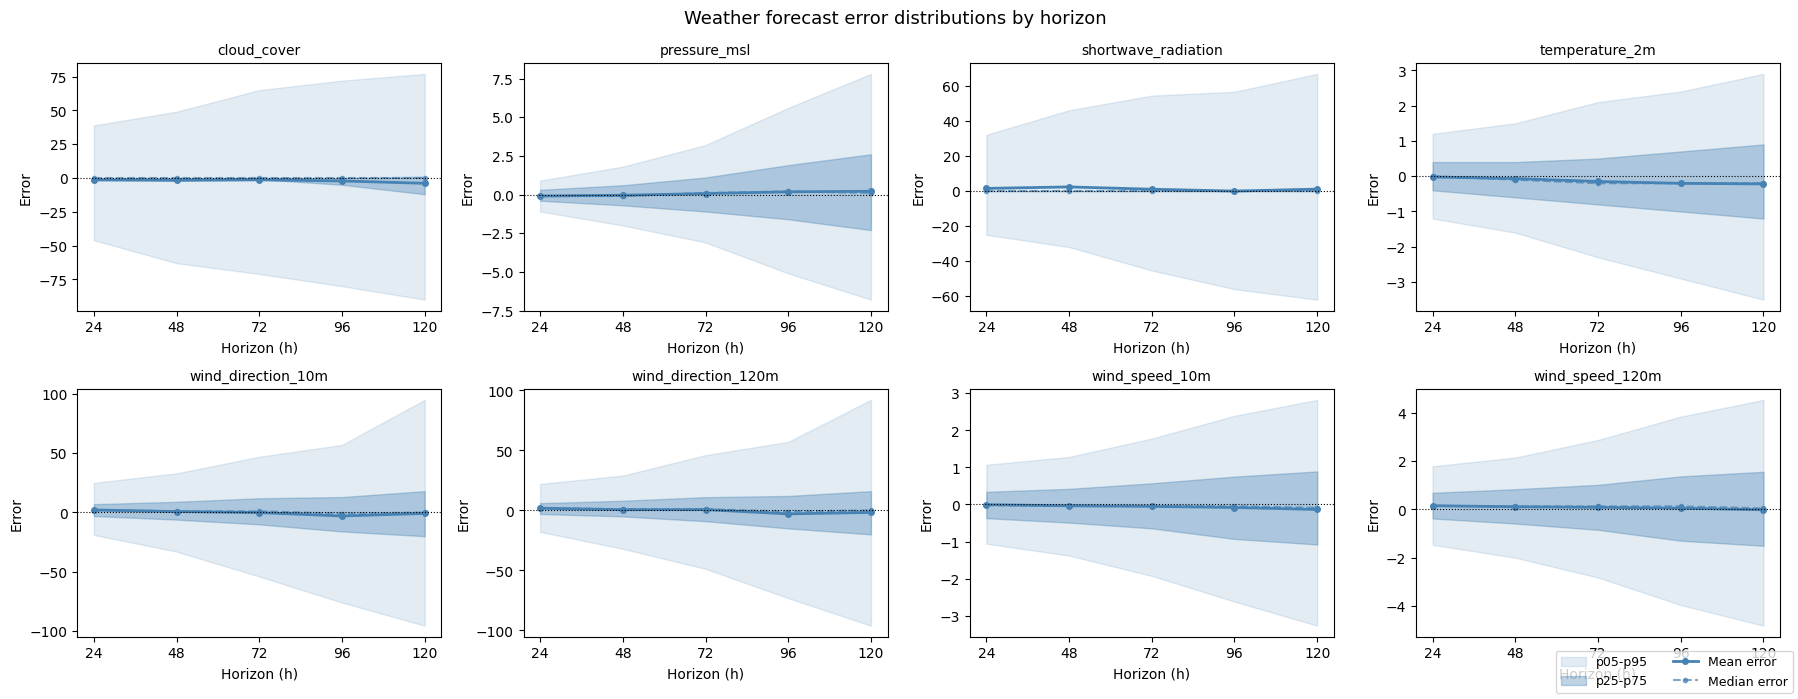

In [13]:
from src.data.data_processing import plot_weather_error_distributions

plot_weather_error_distributions()

<!-- Because the error distributions are estimated only from the period where real NWP forecasts are available (2025 onwards), we can use them to extend the forecast data all the way back to 2021. For each hour in the full historical period, we take the actual observed weather value and add a random error drawn from the matching distribution for that variable and horizon. This gives us a synthetic forecast value that behaves statistically like a real NWP forecast — accurate at short horizons and increasingly uncertain further out. The result is a complete dataset of simulated 120-hour forecasts spanning 2021 to present, which becomes the direct input to the XGBoost model -->

Across all variables, the error distributions widen as forecast horizon increases, which is expected as uncertainty grows further into the future. 

Because the error distributions are estimated only from the period where real NWP forecasts are available (2025 onwards), we can use them to extend the forecast data all the way back to 2021. For each hour in the full historical period, we take the actual observed weather value and add a random error drawn from the matching distribution for that variable and horizon. This gives us a synthetic forecast value that behaves statistically like a real NWP forecast — accurate at short horizons and increasingly uncertain further out. The result is a complete dataset of simulated 120-hour forecasts spanning 2021 to present, which becomes the direct input to the XGBoost model.

In the plot below, we can see how the simulated forecast drifts further from the actual observations as the horizon increases — short-term predictions stay close to the actuals while longer-horizon values show larger deviations.

In [14]:
from src.data.data_processing import plot_weather_forecast_dashboard_style

fig_weather = plot_weather_forecast_dashboard_style(
    issue_time="2026-04-23 00:00",
    ctx_days=7,
    show_actuals=True,
)

For each issue time, 120 rows are created — one per forecast horizon from 1 to 120 hours ahead. This means that a single issue time at midnight will have one row predicting the price 1 hour ahead, another predicting 24 hours ahead, another predicting 120 hours ahead, and everything in between. Each of these rows carries different feature values, since the simulated weather forecast for hour 1 is more accurate than for hour 120, and the horizon itself is included as a feature so the model learns that uncertainty grows with distance. Each row combines the simulated NWP weather values at that specific horizon, cyclic time features (sin/cos of hour and day-of-year), and price lags at 24h, 48h, and 168h relative to the issue time. The result is forecast_dataset.parquet, with one row per (issue_time, horizon_h) pair across the full 2021–present period. This structure ensures the model only ever sees information that would have been available at the moment a forecast was issued — no future prices, no future weather — making the walk-forward evaluation a realistic measure of how well the model would perform in practice.  

The code below simulates the weather data and generates the dataset. This function takes a while

In [28]:
!python -m src.data.data_processing

Data processing from 2021-01-08 to 2026-04-28 is done.
Actual weather forecasts from 2021-01-01 to 2026-04-29 were used to estimate forecast errors and generate forecast-like weather inputs.


c:\Users\User\Documents\GitHub\Advanced-Business-Analytics\src\data\data_processing.py:506: RuntimeWarning: Mean of empty slice
  "price_rolling_24h_mean": np.nanmean(past_24),


Below is a short overview of how the final data is structured. 

In [29]:
display_data=pd.read_parquet("data/model_dataset.parquet")
display_data.head()

,region,issue_time,target_time,horizon_h,hour_of_day,day_of_week,month,is_weekend,sin_hour,cos_hour,sin_doy,cos_doy,fcst_wind_speed_10m,actual_wind_speed_10m,fcst_wind_direction_10m,actual_wind_direction_10m,fcst_wind_speed_100m,actual_wind_speed_100m,fcst_wind_direction_100m,actual_wind_direction_100m,fcst_shortwave_radiation,actual_shortwave_radiation,fcst_cloud_cover,actual_cloud_cover,fcst_temperature_2m,actual_temperature_2m,fcst_pressure_msl,actual_pressure_msl,DayAheadPriceEUR,price_lag_24h,price_lag_48h,price_lag_168h,price_rolling_24h_mean,fcst_wind_dir_10m_sin,fcst_wind_dir_10m_cos,fcst_wind_dir_100m_sin,fcst_wind_dir_100m_cos
0,DK1_west,2021-01-08,2021-01-08 01:00:00,1,1,4,1,0,0.26,0.97,0.14,0.99,3.40,3.38,18.38,19.00,6.26,6.22,28.35,28.00,0.00,0.00,99.05,100.00,-0.60,-0.60,1012.48,1012.50,47.38,43.08,29.83,50.87,67.69,0.32,0.95,0.47,0.88
1,DK1_west,2021-01-08,2021-01-08 02:00:00,2,2,4,1,0,0.50,0.87,0.14,0.99,3.42,3.40,27.26,24.00,6.31,6.33,31.98,31.00,0.00,0.00,99.93,100.00,-0.20,-0.20,1012.48,1012.50,45.78,43.08,29.83,50.87,67.69,0.46,0.89,0.53,0.85
2,DK1_west,2021-01-08,2021-01-08 03:00:00,3,3,4,1,0,0.71,0.71,0.14,0.99,3.47,3.55,23.09,22.00,6.38,6.40,27.12,29.00,0.00,0.00,100.00,99.00,-0.09,-0.10,1012.47,1012.50,44.51,43.08,29.83,50.87,67.69,0.39,0.92,0.46,0.89
3,DK1_west,2021-01-08,2021-01-08 04:00:00,4,4,4,1,0,0.87,0.50,0.14,0.99,3.35,3.20,14.36,20.00,6.43,6.18,26.56,29.00,0.00,0.00,96.62,96.00,-0.38,-0.30,1012.58,1012.70,45.69,43.08,29.83,50.87,67.69,0.25,0.97,0.45,0.89
4,DK1_west,2021-01-08,2021-01-08 05:00:00,5,5,4,1,0,0.97,0.26,0.14,0.99,3.32,3.13,25.02,17.00,6.20,6.22,27.68,26.00,0.00,0.00,98.99,99.00,-0.51,-0.80,1012.60,1012.90,50.33,43.08,29.83,50.87,67.69,0.42,0.91,0.46,0.89
